In [250]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

In [251]:
# Import as Dataframe
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [252]:
ser = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')
ser.head()

,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
Date,,,,,,,,,,
2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


## Visualizing a time series
Let’s use matplotlib to visualise the series.

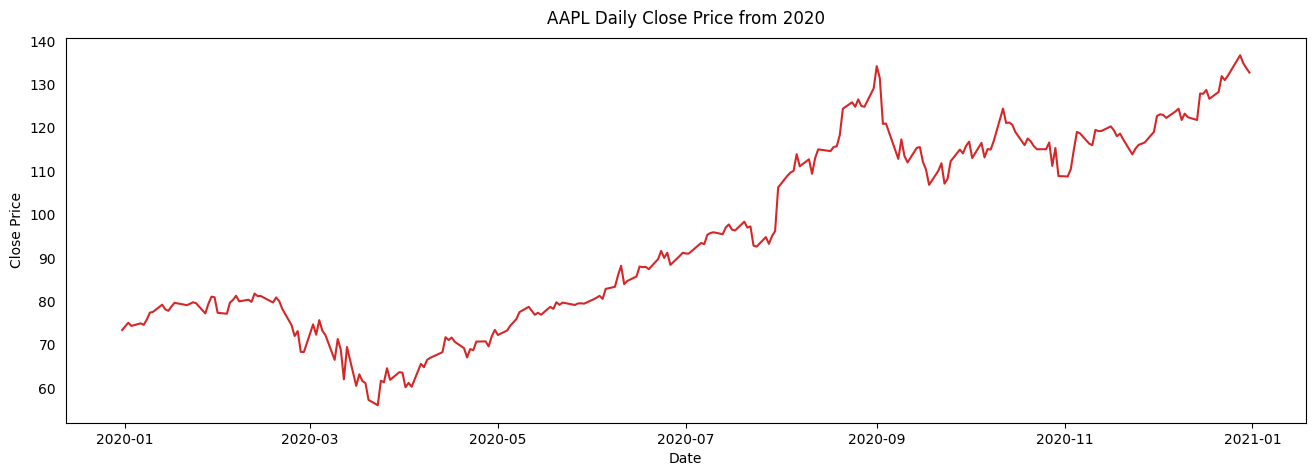

In [253]:
# Time series data source: fpp pacakge data.
import matplotlib.pyplot as plt
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')

# Draw Plot
def plot_df(df, x, y, title="", xlabel='date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df['Close'], title='AAPL Daily Close Price from 2020',
            xlabel='Date',  ylabel='Close Price')    

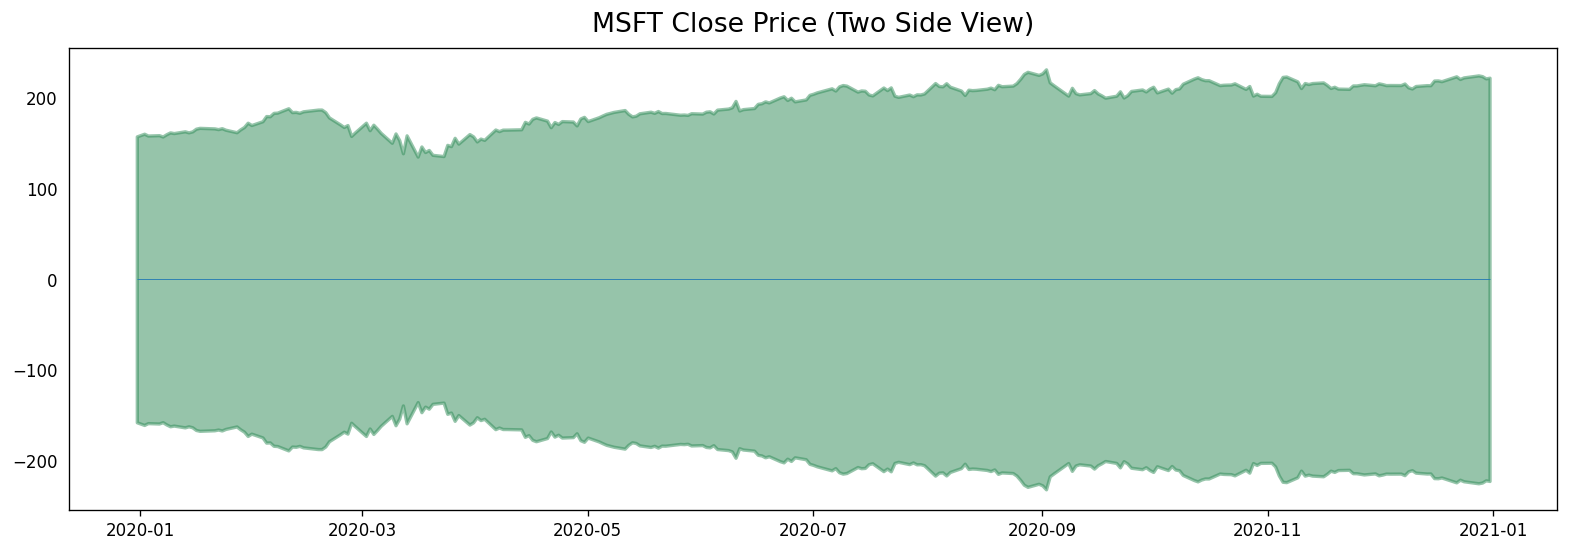

In [254]:
# Import data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'])
x = df['Date'].values
y1 = df['Close'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')

plt.title('MSFT Close Price (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df.Date), xmax=np.max(df.Date), linewidth=.5)
plt.show()

Seasonal Plot of a Time Series

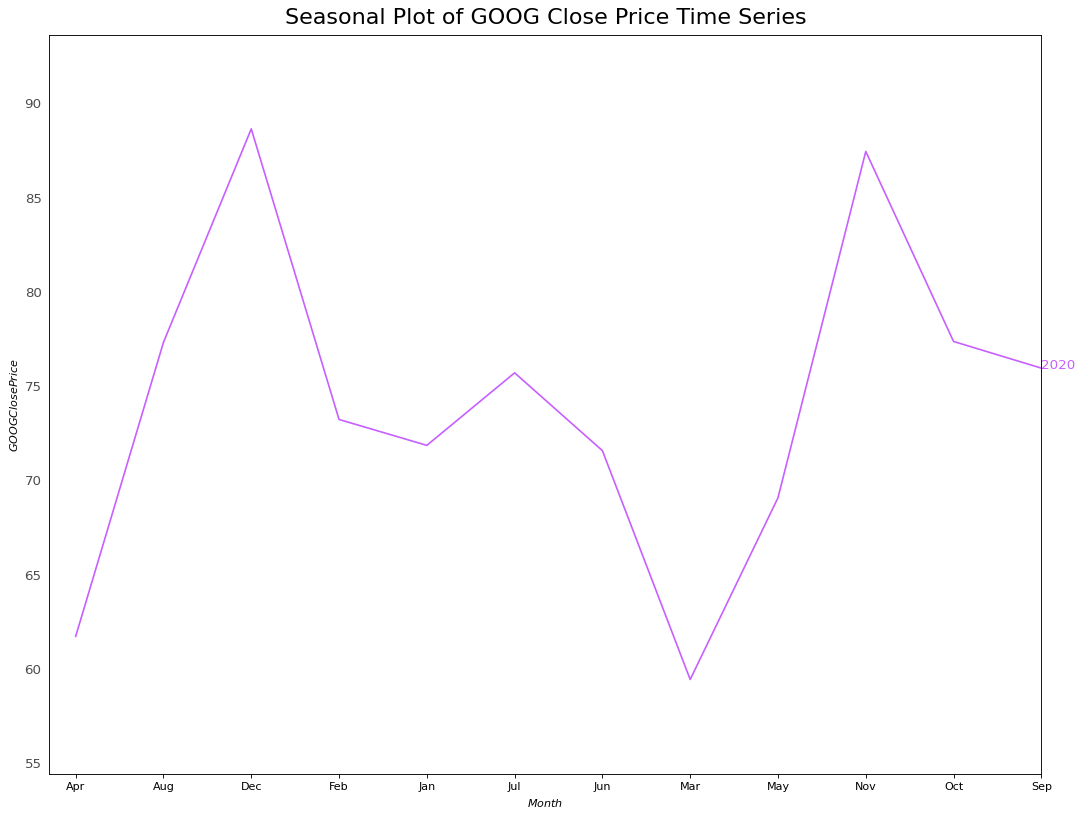

In [255]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/goog_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]

df = df.groupby(['year', 'month'])['Close'].mean().reset_index()

years = df['year'].unique()

# Prep Colors
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Draw Plot
plt.figure(figsize=(16,12), dpi= 80)

for i, y in enumerate(years):
    if i > 0:
       plt.plot('month', 'Close', data=df.loc[df.year==y, :], color=mycolors[i], label=y)
       plt.text(11, df.loc[df.year==y, 'Close'].iloc[-1], y, fontsize=12, color=mycolors[i])

# Decoration
plt.gca().set(xlim=(-0.3, 11), ylabel='$GOOG Close Price$', xlabel='$Month$')
plt.ylim(df['Close'].min()-5, df['Close'].max()+5)
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot of GOOG Close Price Time Series", fontsize=20)
plt.show()

Boxplot of Month-wise (Seasonal) and Year-wise (trend) Distribution

/tmp/ipykernel_280919/1654267955.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
/tmp/ipykernel_280919/1654267955.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')


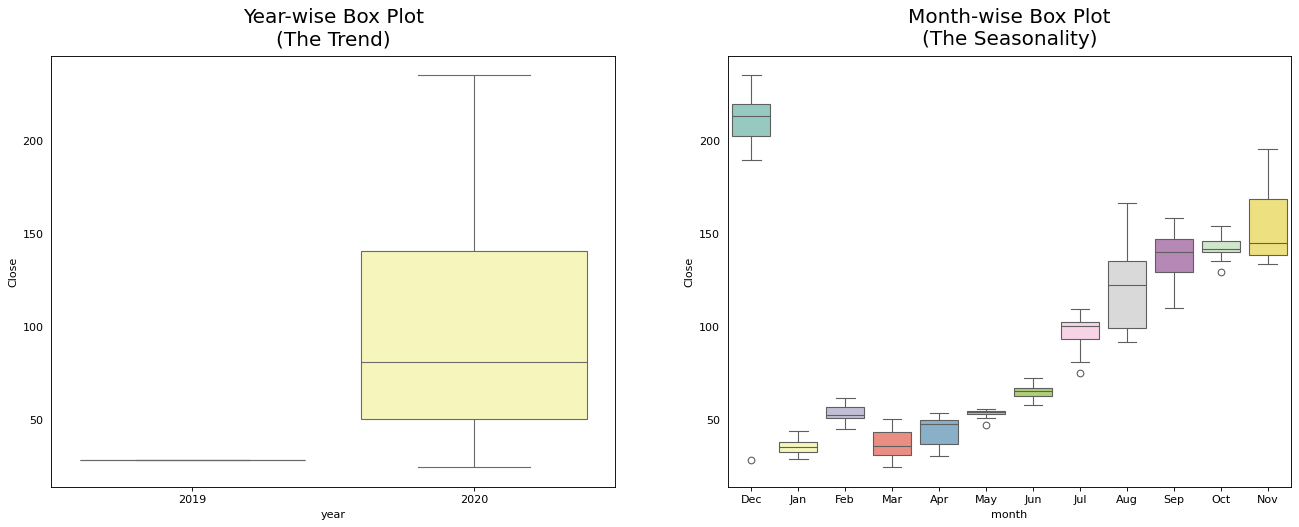

In [256]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]
years = df['year'].unique()

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

/tmp/ipykernel_280919/909635879.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
/tmp/ipykernel_280919/909635879.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')


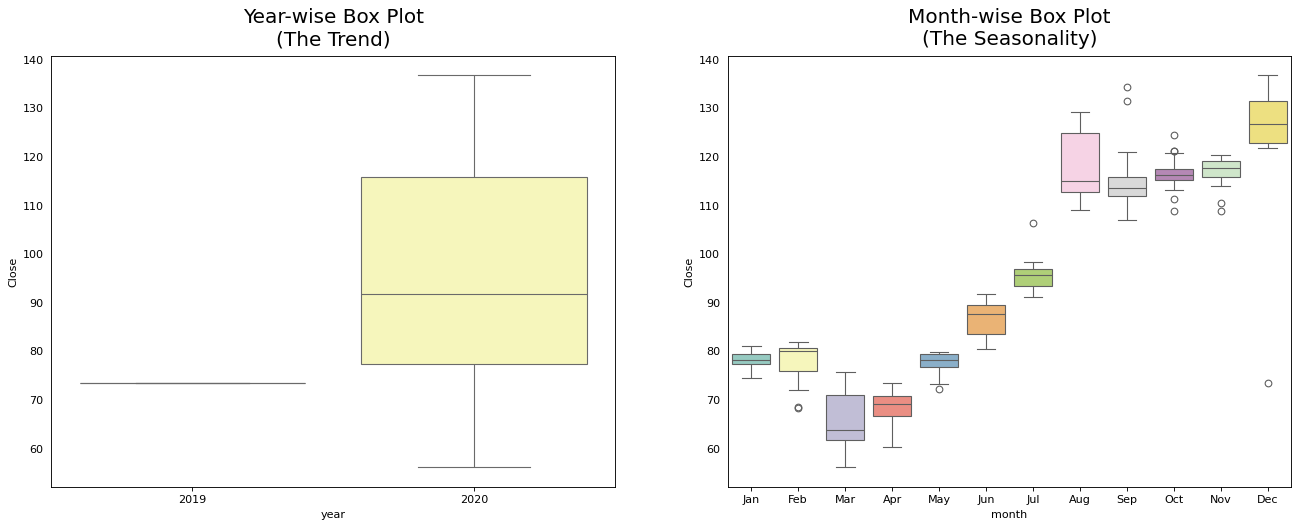

In [257]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]
years = df['year'].unique()

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

Patterns in a time series

<Axes: title={'center': 'Trend and Seasonality'}, xlabel='Date'>

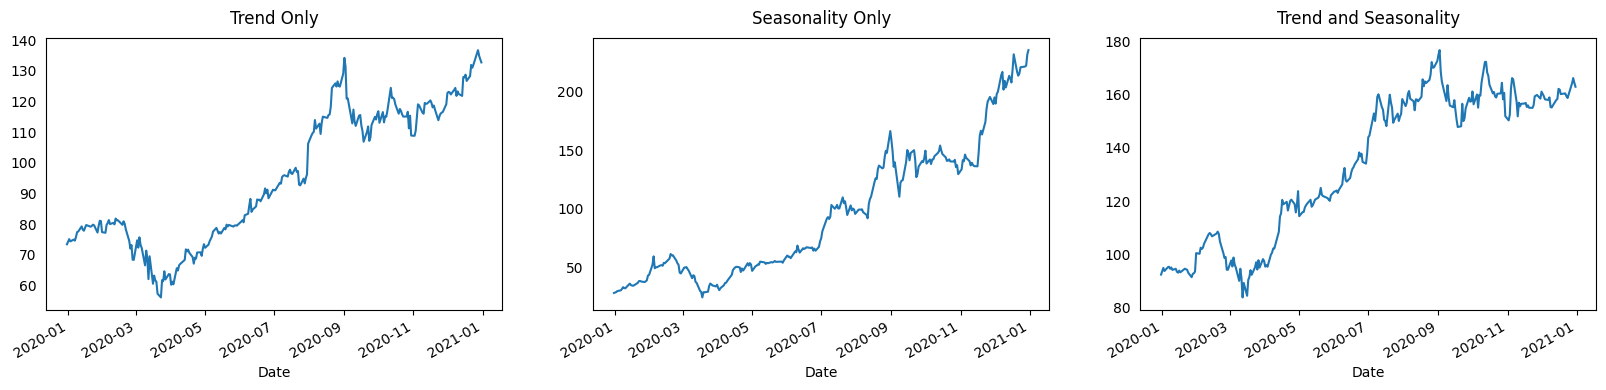

In [258]:
fig, axes = plt.subplots(1,3, figsize=(20,4), dpi=100)
pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Trend Only', legend=False, ax=axes[0])

pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Seasonality Only', legend=False, ax=axes[1])

pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/amzn_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Trend and Seasonality', legend=False, ax=axes[2])

How to decompose a time series into its components?

In [259]:
import sys
!{sys.executable} -m pip install statsmodels

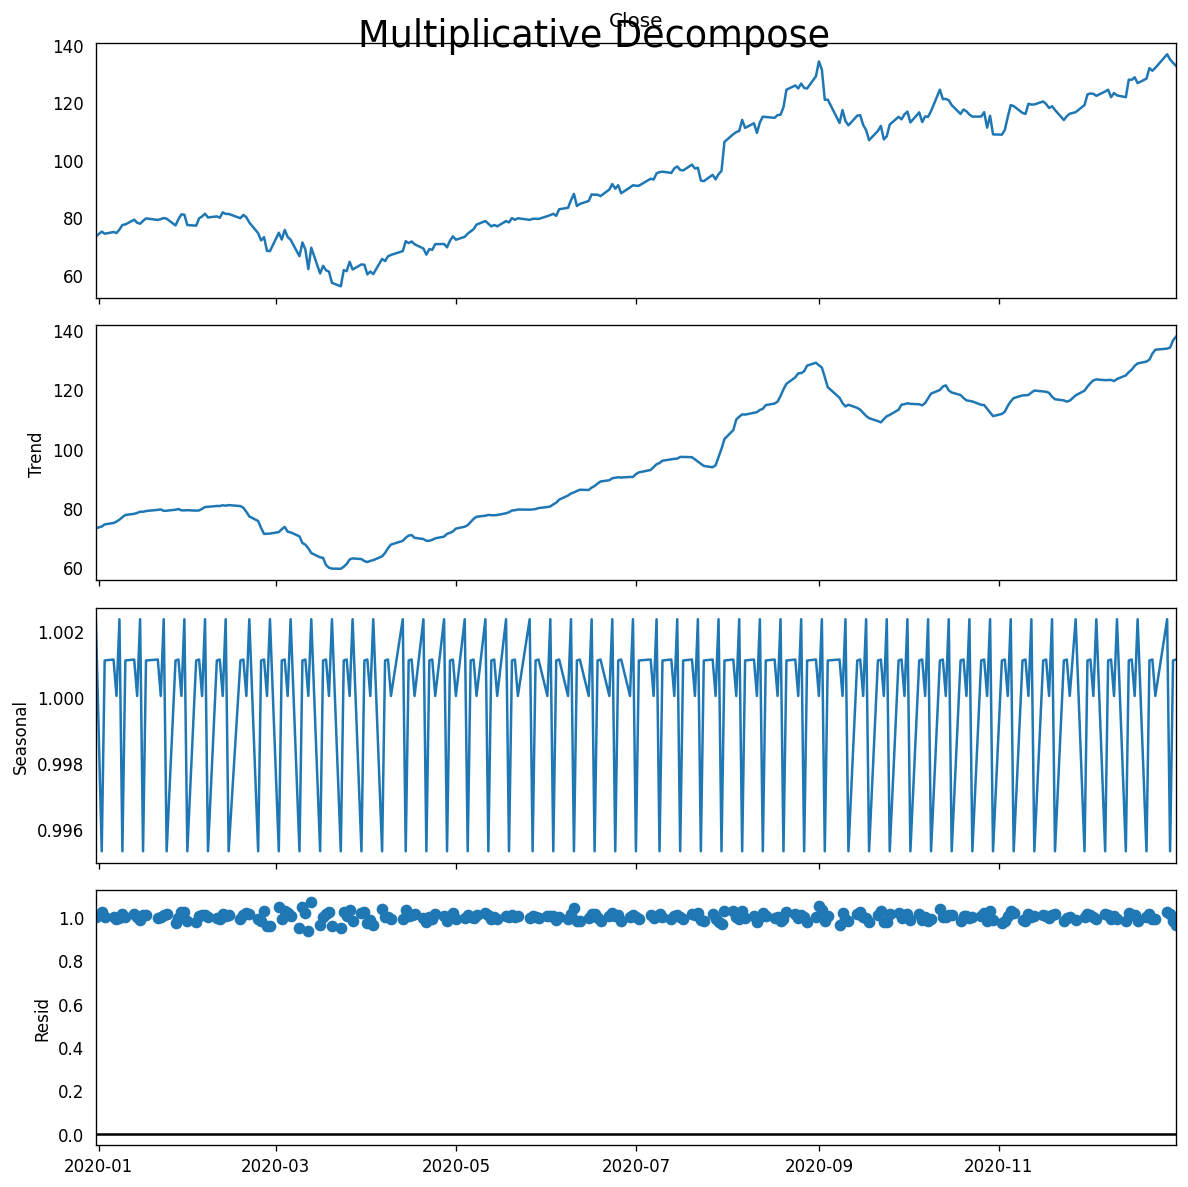

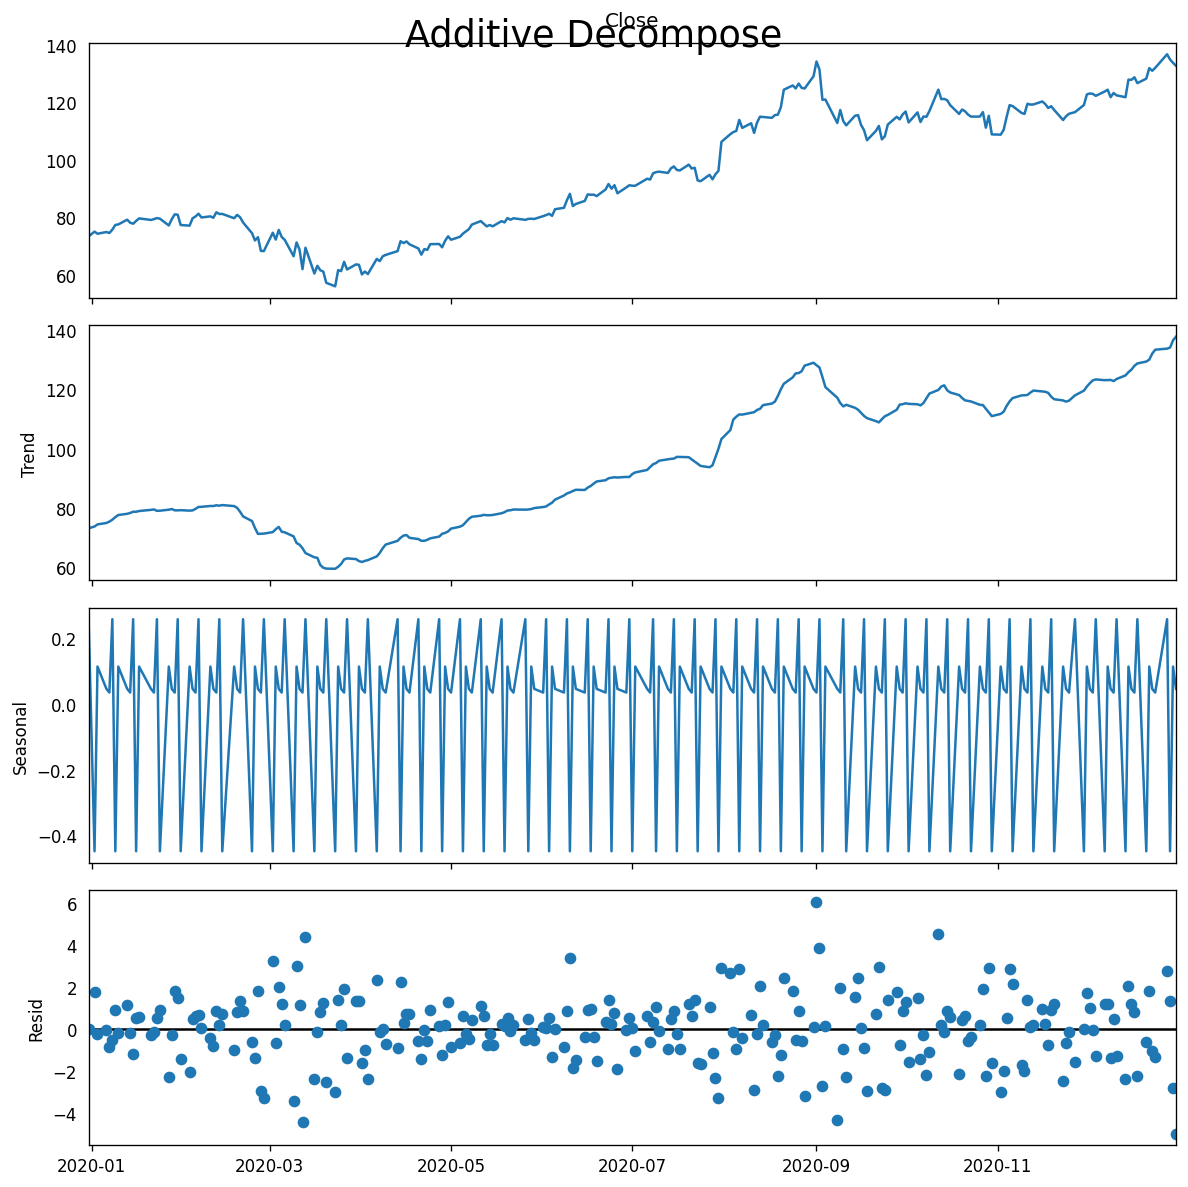

In [260]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
%matplotlib inline

# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')

# Multiplicative Decomposition 
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')

# Additive Decomposition
result_add = seasonal_decompose(df['Close'], model='additive', period=5, extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (10,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

In [261]:
# Extract the Components ----
# Actual Values = Product of (Seasonal * Trend * Resid)
df_reconstructed = pd.concat([result_mul.seasonal, result_mul.trend, result_mul.resid, result_mul.observed], axis=1)
df_reconstructed.columns = ['seas', 'trend', 'resid', 'actual_values']
df_reconstructed.head()

,seas,trend,resid,actual_values
Date,,,,
2019-12-31,1.002364,73.1718,1.000923,73.412498
2020-01-02,0.995337,73.7715,1.022607,75.087502
2020-01-03,1.001114,74.4810,0.997231,74.357498
2020-01-06,1.001144,74.9580,0.998751,74.949997
2020-01-07,1.000041,75.4220,0.989028,74.597504


In [262]:
from statsmodels.tsa.stattools import adfuller, kpss
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])

# ADF Test
result = adfuller(df['Close'].values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

# KPSS Test
result = kpss(df['Close'].values, regression='c')
print('\nKPSS Statistic: %f' % result[0])
print('p-value: %f' % result[1])
for key, value in result[3].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -0.12702885454878415
p-value: 0.9466789170863883
Critial Values:
   1%, -3.4565688966099373
Critial Values:
   5%, -2.8730786194395455
Critial Values:
   10%, -2.5729189953388762

KPSS Statistic: 2.143463
p-value: 0.010000
Critial Values:
   10%, 0.347
Critial Values:
   5%, 0.463
Critial Values:
   2.5%, 0.574
Critial Values:
   1%, 0.739


/tmp/ipykernel_280919/3631784808.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df['Close'].values, regression='c')


Noise and a stationary series

<Axes: title={'center': 'AAPL Returns'}>

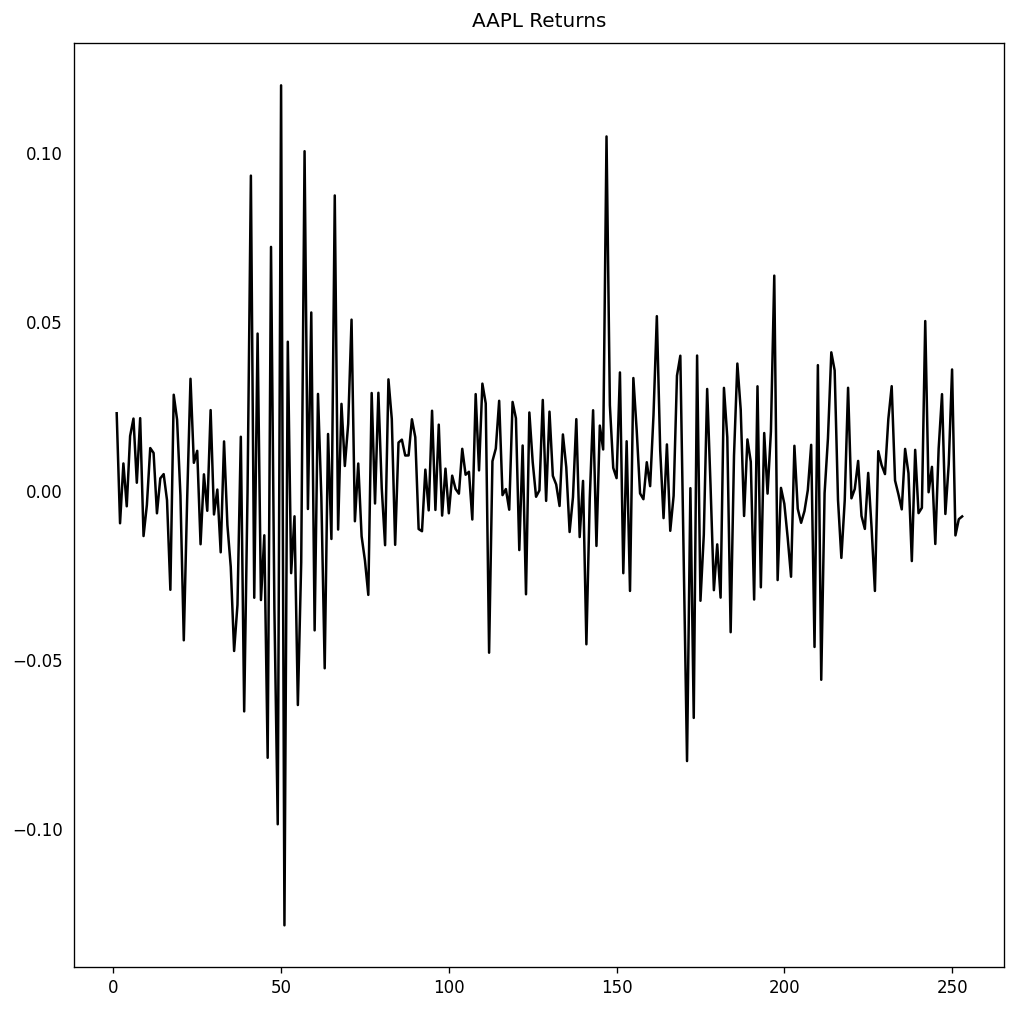

In [263]:
df['Returns'] = df['Close'].pct_change()

df['Returns'].plot(
    title='AAPL Returns',
    color='k'
)

How to detrend a time series?

Text(0.5, 1.0, 'Drug Sales detrended by subtracting the least squares fit')

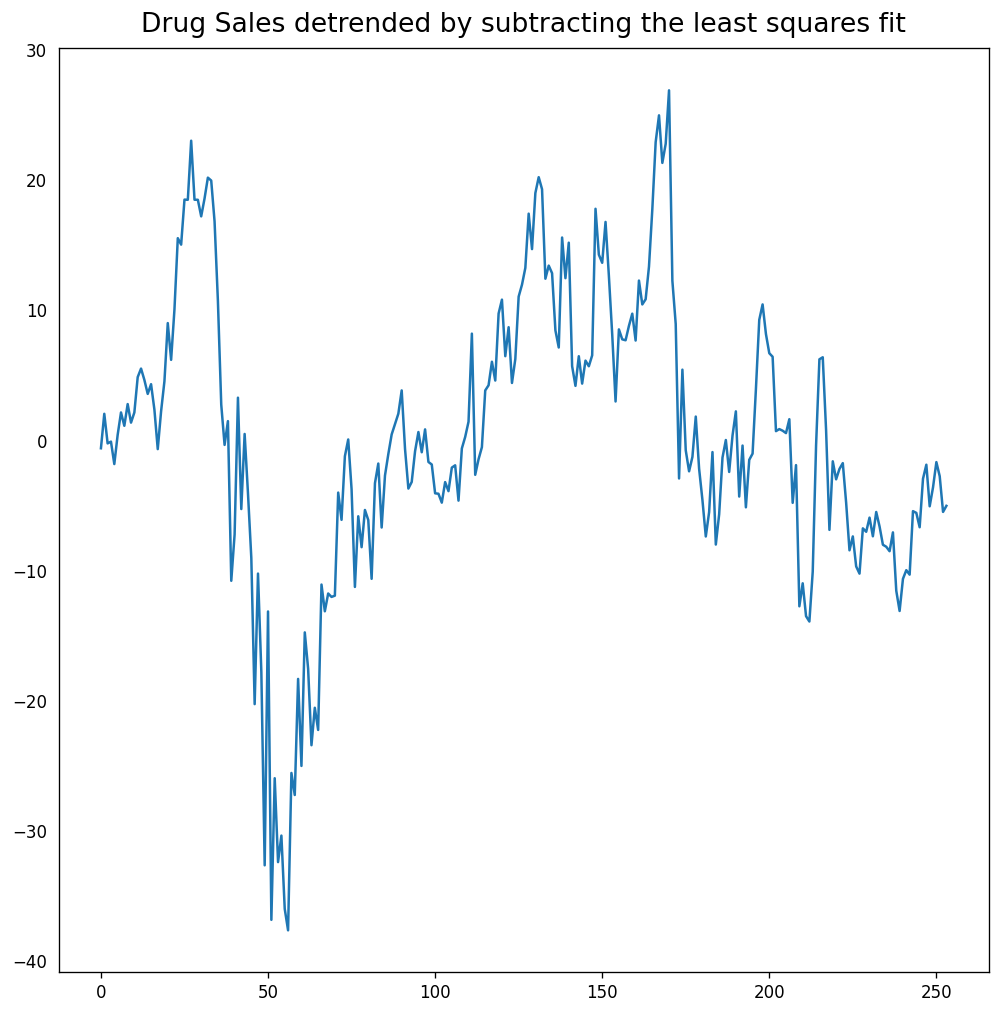

In [264]:
# Using scipy: Subtract the line of best fit
from scipy import signal
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'])
detrended = signal.detrend(df['Close'].values)
plt.plot(detrended)
plt.title('Drug Sales detrended by subtracting the least squares fit', fontsize=16)

Text(0.5, 1.0, 'MSFT Close Price Detrended by Subtracting the Trend Component')

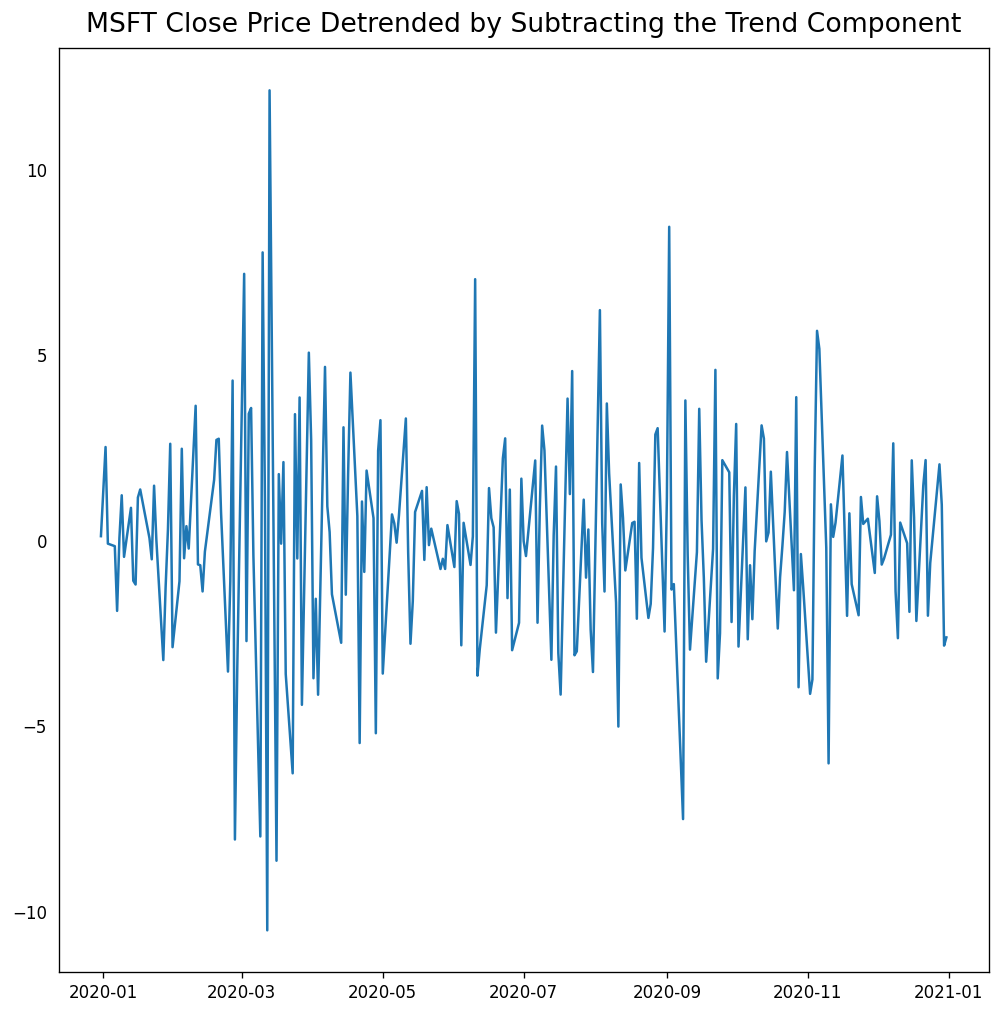

In [265]:
# Using statmodels: Subtracting the Trend Component.
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'], index_col='Date')
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')
detrended = df['Close'].values - result_mul.trend
plt.plot(detrended)
plt.title('MSFT Close Price Detrended by Subtracting the Trend Component', fontsize=16)

How to deseasonalize a time series?

[]

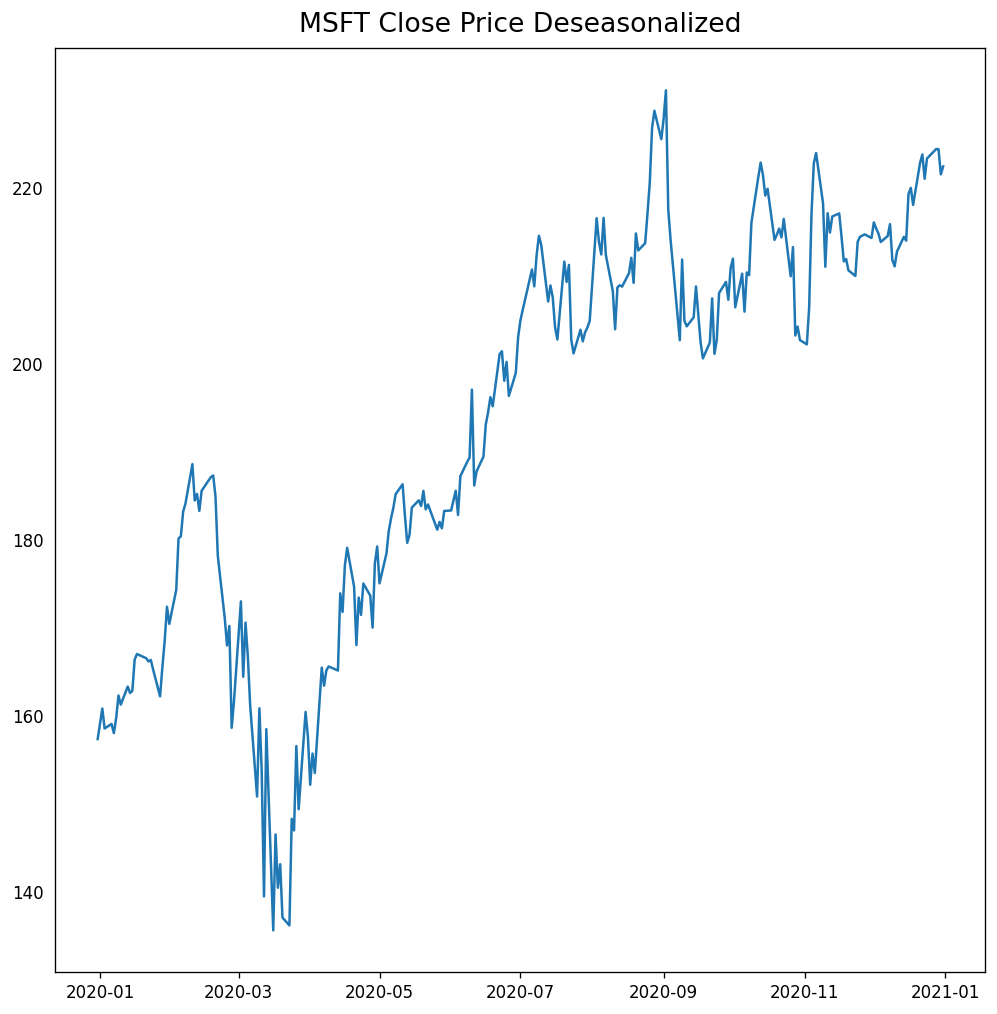

In [266]:
# Subtracting the Trend Component.
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'], index_col='Date')

# Time Series Decomposition
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')

# Deseasonalize
deseasonalized = df['Close'].values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title('MSFT Close Price Deseasonalized', fontsize=16)
plt.plot()

How to test for seasonality of a time series?

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

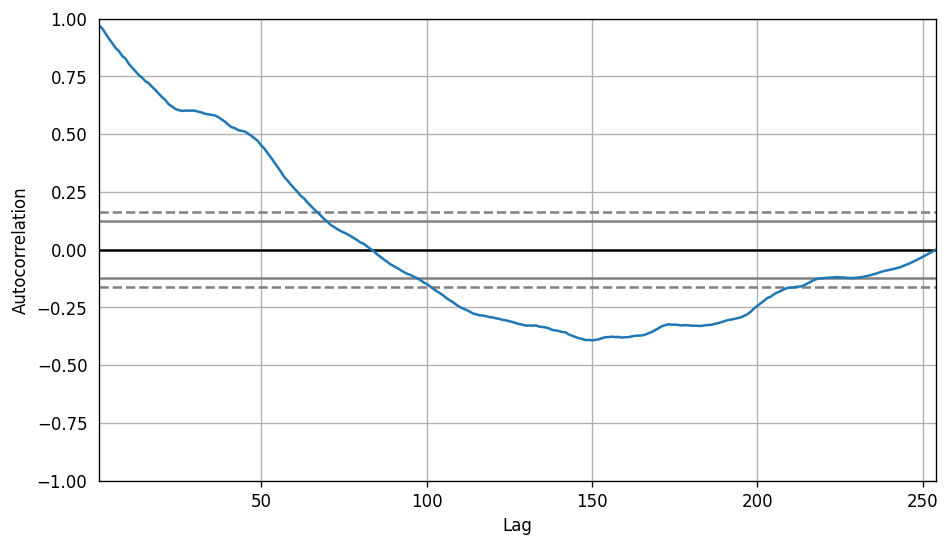

In [267]:
from pandas.plotting import autocorrelation_plot
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')

# Draw Plot
plt.rcParams.update({'figure.figsize':(9,5), 'figure.dpi':120})
autocorrelation_plot(df['Close'].tolist())

What is autocorrelation and partial autocorrelation functions?

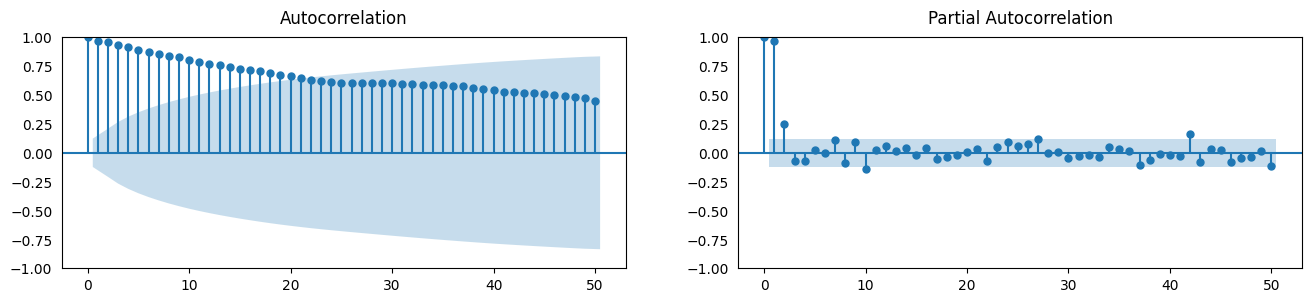

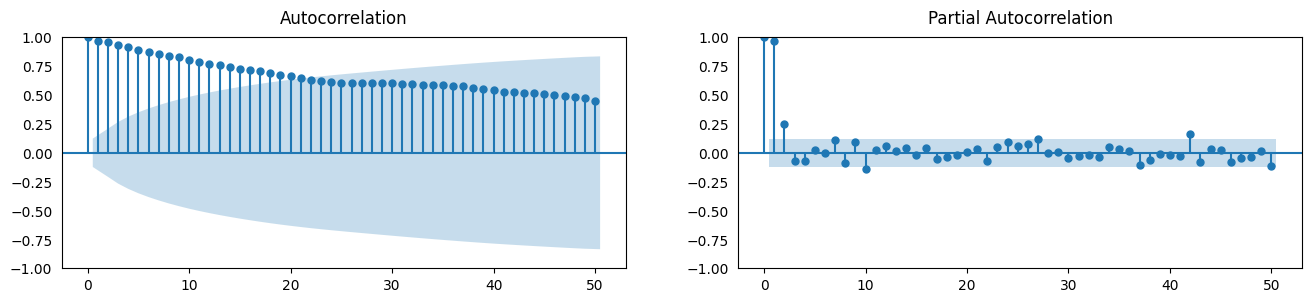

In [268]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')

# Calculate ACF and PACF upto 50 lags
# acf_50 = acf(df['Close'], nlags=50)
# pacf_50 = pacf(df['Close'], nlags=50)

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Close'].tolist(), lags=50, ax=axes[0])
plot_pacf(df['Close'].tolist(), lags=50, ax=axes[1])

Lag Plots

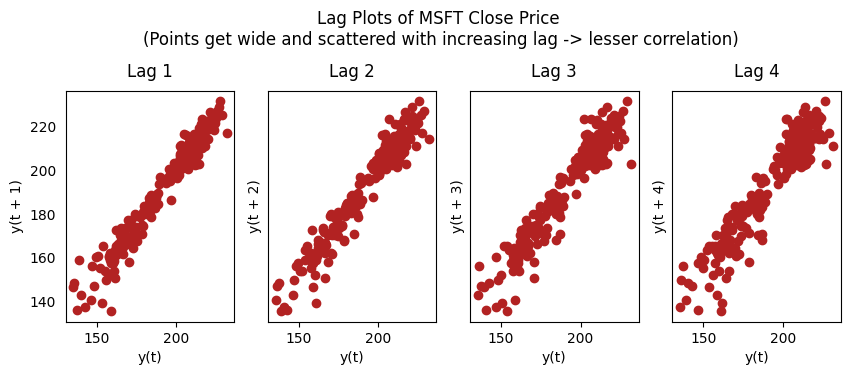

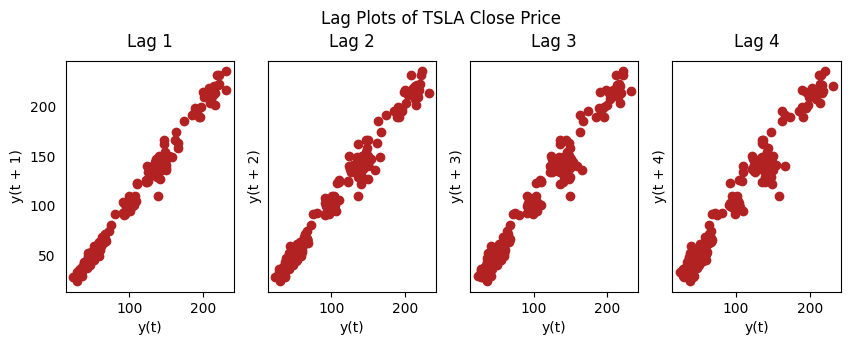

In [269]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Import
ss = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')
a10 = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv')

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(ss['Close'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of MSFT Close Price \n(Points get wide and scattered with increasing lag -> lesser correlation)\n', y=1.15)    

fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(a10['Close'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of TSLA Close Price', y=1.05)    
plt.show()


How to estimate the forecastability of a time series?

In [270]:
# https://en.wikipedia.org/wiki/Approximate_entropy
ss = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')
a10 = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv') # drug sells
rand_small = np.random.randint(0, 100, size=36)
rand_big = np.random.randint(0, 100, size=136)

def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

print(ApEn(ss['Close'], m=2, r=0.2*np.std(ss['Close'])))     # 0.651
print(ApEn(a10['Close'], m=2, r=0.2*np.std(a10['Close'])))   # 0.537
print(ApEn(rand_small, m=2, r=0.2*np.std(rand_small))) # 0.143
print(ApEn(rand_big, m=2, r=0.2*np.std(rand_big)))     # 0.716

0.5710304061990947
0.21796380994290088
0.16083502693096996
0.5972926771842966


In [271]:
# https://en.wikipedia.org/wiki/Sample_entropy
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

print(SampEn(ss['Close'], m=2, r=0.2*np.std(ss['Close'])))      # 0.78
print(SampEn(a10['Close'], m=2, r=0.2*np.std(a10['Close'])))    # 0.41
print(SampEn(rand_small, m=2, r=0.2*np.std(rand_small)))  # 1.79
print(SampEn(rand_big, m=2, r=0.2*np.std(rand_big)))      # 2.42

0.47085308294367295
0.14156356432178688
inf
2.0794415416798357


/tmp/ipykernel_280919/2064711045.py:13: RuntimeWarning: divide by zero encountered in log
  return -np.log(_phi(m+1) / _phi(m))


How to use Granger Causality test to know if one time series is helpful in forecasting another?

In [272]:
from statsmodels.tsa.stattools import grangercausalitytests
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])

# Remove missing values
df = df[['Close', 'avg_sentiment']].dropna()

grangercausalitytests(df[['Close', 'avg_sentiment']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1741  , p=0.6768  , df_denom=250, df_num=1
ssr based chi2 test:   chi2=0.1762  , p=0.6746  , df=1
likelihood ratio test: chi2=0.1762  , p=0.6747  , df=1
parameter F test:         F=0.1741  , p=0.6768  , df_denom=250, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6402  , p=0.5281  , df_denom=247, df_num=2
ssr based chi2 test:   chi2=1.3062  , p=0.5204  , df=2
likelihood ratio test: chi2=1.3029  , p=0.5213  , df=2
parameter F test:         F=0.6402  , p=0.5281  , df_denom=247, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(0.17414346239183137),
    np.float64(0.6768134685795656),
    np.float64(250.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.17623318394053333),
    np.float64(0.6746305694912718),
    np.int64(1)),
   'lrtest': (np.float64(0.17617183271568138),
    np.float64(0.6746839601616024),
    np.int64(1)),
   'params_ftest': (np.float64(0.17414346239159437),
    np.float64(0.6768134685797728),
    np.float64(250.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.6401622014996868),
    np.float64(0.5280793235955015),
    np.float64(247.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.3062419010357982),
    np.float64(0.5204190375304039),
    np.int64(2)),
   'lrtest': (np.float64(1.3028681025452897),
    np.float64(0.5212976728883347),
    np.int64(2)),
   'params_ftest': (np.float64(0.6401622014996571),
    np.float64(0.5280793235955171),
    np.float64(247.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
  